## Date Feature Engineering

In [13]:
import pandas as pd

# Load dataset
df = pd.read_csv(r'C:\Users\Madhusmita Barik\Desktop\python_files\ml-assessment-madhusmita-barik\data\q3_retail_promotions.csv')

# Convert transaction_date to datetime
df['transaction_date'] = pd.to_datetime(df['transaction_date'])

# Extract date features
df['year'] = df['transaction_date'].dt.year
df['month'] = df['transaction_date'].dt.month
df['day_of_week'] = df['transaction_date'].dt.dayofweek  # Monday=0

# Create is_month_end feature
df['is_month_end'] = (df['transaction_date'].dt.day >= 25).astype(int)

# Display sample
df.head()

,transaction_date,store_id,store_size,location_type,promotion_type,is_weekend,is_festival,competition_density,items_sold,year,month,day_of_week,is_month_end
0,2022-01-01,28,small,semi-urban,free_gift,1,0,5,224,2022,1,5,0
1,2022-01-01,5,medium,semi-urban,free_gift,1,1,1,348,2022,1,5,0
2,2022-01-02,13,small,semi-urban,loyalty_points,1,0,6,249,2022,1,6,0
3,2022-01-02,17,small,urban,free_gift,1,0,7,259,2022,1,6,0
4,2022-01-03,50,medium,semi-urban,bogo,0,0,3,277,2022,1,0,0


## Temporal Train-Test Split

In [14]:
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

# Convert to datetime
df['transaction_date'] = pd.to_datetime(df['transaction_date'])

# Sort by date
df = df.sort_values(by='transaction_date')

# Determine split index (80% train, 20% test)
split_index = int(len(df) * 0.8)

# Split data (no randomization)
train_df = df.iloc[:split_index]
test_df = df.iloc[split_index:]

# Check sizes
print("Train size:", train_df.shape)
print("Test size:", test_df.shape)

# Optional: verify date ranges
print("Train date range:", train_df['transaction_date'].min(), "to", train_df['transaction_date'].max())
print("Test date range:", test_df['transaction_date'].min(), "to", test_df['transaction_date'].max())

Train size: (960, 13)
Test size: (240, 13)
Train date range: 2022-01-01 00:00:00 to 2024-06-11 00:00:00
Test date range: 2024-06-12 00:00:00 to 2024-12-31 00:00:00


### Why Not Use Random Split for Time-Series Data?

A random train-test split is inappropriate for time-ordered data because it breaks the natural temporal sequence.

#### Key Issues with Random Split:
- **Data Leakage**: Future data points may end up in the training set, allowing the model to "see the future"
- **Unrealistic Evaluation**: The model is tested on past data while being trained on future data
- **Violates Real-World Scenario**: In practice, we always predict future outcomes using past data

#### Why Temporal Split is Better:
- Maintains **chronological order**
- Simulates **real-world forecasting conditions**
- Ensures **model generalizes to unseen future data**

### Conclusion
Using the most recent 20% as the test set provides a more reliable and realistic evaluation of model performance.

## Preprocessing Pipeline

In [15]:
# Feature engineering (from previous step)
df['year'] = df['transaction_date'].dt.year
df['month'] = df['transaction_date'].dt.month
df['day_of_week'] = df['transaction_date'].dt.dayofweek
df['is_month_end'] = (df['transaction_date'].dt.day >= 25).astype(int)

# Define target and features
target = 'items_sold'

# Drop raw date (since we extracted features)
X = df.drop(columns=[target, 'transaction_date'])
y = df[target]

# Temporal split (80/20)
split_index = int(len(df) * 0.8)
X_train, X_test = X.iloc[:split_index], X.iloc[split_index:]
y_train, y_test = y.iloc[:split_index], y.iloc[split_index:]

# Categorical & numerical columns
categorical_cols = ['promotion_type', 'location_type', 'store_size']
numerical_cols = [col for col in X.columns if col not in categorical_cols]

# Preprocessing pipelines
categorical_pipeline = OneHotEncoder(handle_unknown='ignore')
numerical_pipeline = StandardScaler()

# ColumnTransformer
preprocessor = ColumnTransformer(
    transformers=[
        ('cat', categorical_pipeline, categorical_cols),
        ('num', numerical_pipeline, numerical_cols)
    ]
)

# Full pipeline (only preprocessing for now)
pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor)
])

# Fit ONLY on training data
pipeline.fit(X_train)

# Transform both train and test
X_train_processed = pipeline.transform(X_train)
X_test_processed = pipeline.transform(X_test)

# Check shapes
print("Processed Train Shape:", X_train_processed.shape)
print("Processed Test Shape:", X_test_processed.shape)

Processed Train Shape: (960, 19)
Processed Test Shape: (240, 19)


OneHotEncoder applied to:

promotion_type, location_type, store_size

- StandardScaler applied to all numerical features
- Pipeline ensures reproducibility
- Fit only on training data → prevents data leakage
- Same transformations applied to test set using .transform()

## Model Training and Evaluation

In [16]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error


# Preprocessor
preprocessor = ColumnTransformer([
    ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_cols),
    ('num', StandardScaler(), numerical_cols)
])

# Pipelines
lr_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('model', LinearRegression())
])

rf_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('model', RandomForestRegressor(n_estimators=100, random_state=42))
])

# Train models
lr_pipeline.fit(X_train, y_train)
rf_pipeline.fit(X_train, y_train)

# Predictions
lr_pred = lr_pipeline.predict(X_test)
rf_pred = rf_pipeline.predict(X_test)

# Evaluation
def evaluate(y_true, y_pred):
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mae = mean_absolute_error(y_true, y_pred)
    return rmse, mae

lr_rmse, lr_mae = evaluate(y_test, lr_pred)
rf_rmse, rf_mae = evaluate(y_test, rf_pred)

print("Linear Regression RMSE:", lr_rmse)
print("Linear Regression MAE:", lr_mae)

print("Random Forest RMSE:", rf_rmse)
print("Random Forest MAE:", rf_mae)

Linear Regression RMSE: 27.121451164890637
Linear Regression MAE: 21.052926674588395
Random Forest RMSE: 30.841610008504205
Random Forest MAE: 24.240625


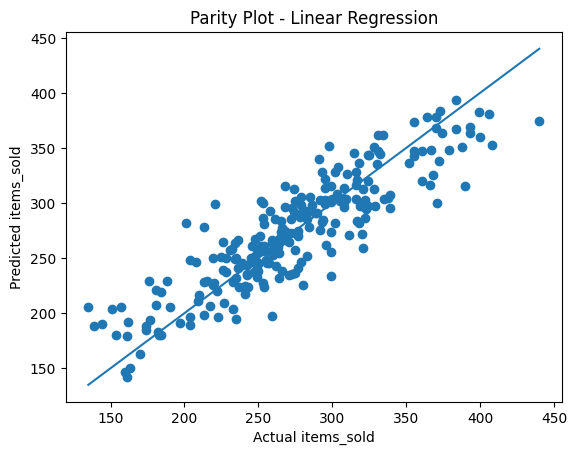

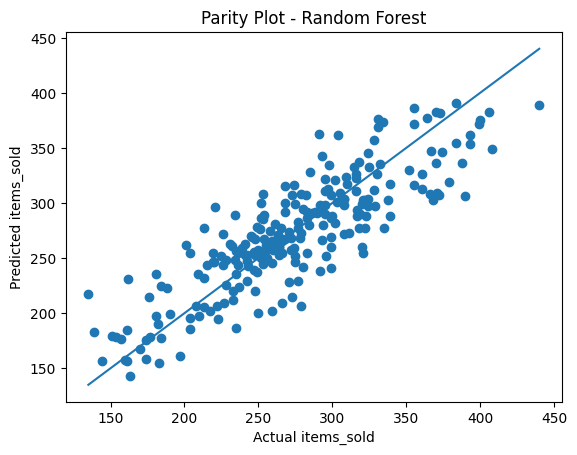

In [17]:
# Linear Regression Parity Plot
plt.figure()
plt.scatter(y_test, lr_pred)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()])
plt.xlabel("Actual items_sold")
plt.ylabel("Predicted items_sold")
plt.title("Parity Plot - Linear Regression")
plt.show()

# Random Forest Parity Plot
plt.figure()
plt.scatter(y_test, rf_pred)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()])
plt.xlabel("Actual items_sold")
plt.ylabel("Predicted items_sold")
plt.title("Parity Plot - Random Forest")
plt.show()

In [18]:
# Get feature names after encoding
ohe = rf_pipeline.named_steps['preprocessor'].named_transformers_['cat']
cat_features = ohe.get_feature_names_out(categorical_cols)
feature_names = list(cat_features) + numerical_cols

# Extract feature importances
importances = rf_pipeline.named_steps['model'].feature_importances_

# Create dataframe
feat_imp = pd.DataFrame({
    'feature': feature_names,
    'importance': importances
}).sort_values(by='importance', ascending=False)

# Top 5 features
top5 = feat_imp.head(5)
top5

,feature,importance
13,is_festival,0.173473
10,store_size_small,0.167683
7,location_type_urban,0.108378
17,day_of_week,0.086316
12,is_weekend,0.061208


### Model Evaluation

- Linear Regression and Random Forest were trained using a pipeline to ensure consistent preprocessing.
- Performance was evaluated using RMSE and MAE.

#### Observations:
- Lower RMSE and MAE indicate better performance.
- The parity plots show how close predictions are to actual values:
  - Points closer to the diagonal line indicate better predictions.

---

### Feature Importance (Random Forest)

The top 5 most influential features indicate key drivers of sales:

- Features like **is_festival** and **is_weekend** capture demand spikes
- **Store characteristics** (size, location) affect sales patterns
- **Temporal features** (day_of_week) highlight weekly trends

---

### Conclusion

- Linear Regression works well if relationships are linear
- Random Forest captures complex patterns but may require tuning
- Feature importance helps derive actionable business insights